# CrossAttn Parameter Sweep

Sweeps the threshold on each of the three pretrained DINOv2+CrossAttn models (ICRA 2025),
then a model-comparison section at the best threshold.

The only real parameter is the threshold — the model is fully pretrained, not a distance metric.
The interesting axis is **which checkpoint generalises best** to our UE renders.

| Checkpoint | Trained on | Scene type |
|---|---|---|
| `dino_2Cross_CMU` | VL-CMU-CD | Outdoor urban streets, **viewpoint changes** between image pairs |
| `dino_2Cross_PSCD` | PSCD | Panoramic retail exteriors, **same viewpoint**, repeated photos |
| `dino_2Cross_DiffCMU` | Diff-CMU | CMU but cleaned — only pixel-diff-confirmed changes |

Our renders are same-viewpoint scene edits, so **PSCD** is the natural first guess,
but all three are worth comparing.

In [9]:
import os, gc
import numpy as np
import torch
import OpenEXR, Imath
from PIL import Image
from pathlib import Path
from torchvision import transforms
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

cwd = Path.cwd().resolve()
if (cwd / 'data').exists() and (cwd / 'change_detection_results').exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / 'data').exists() and (cwd.parent / 'change_detection_results').exists():
    PROJECT_ROOT = cwd.parent.resolve()
else:
    raise FileNotFoundError('Run from repo root or change_detection_results/.')

DATASET  = 'concrete1'   # <- change dataset here
DATA_DIR = PROJECT_ROOT / 'data' / DATASET
device   = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device.upper()}  |  Dataset: {DATASET}')

Device: CUDA  |  Dataset: concrete1


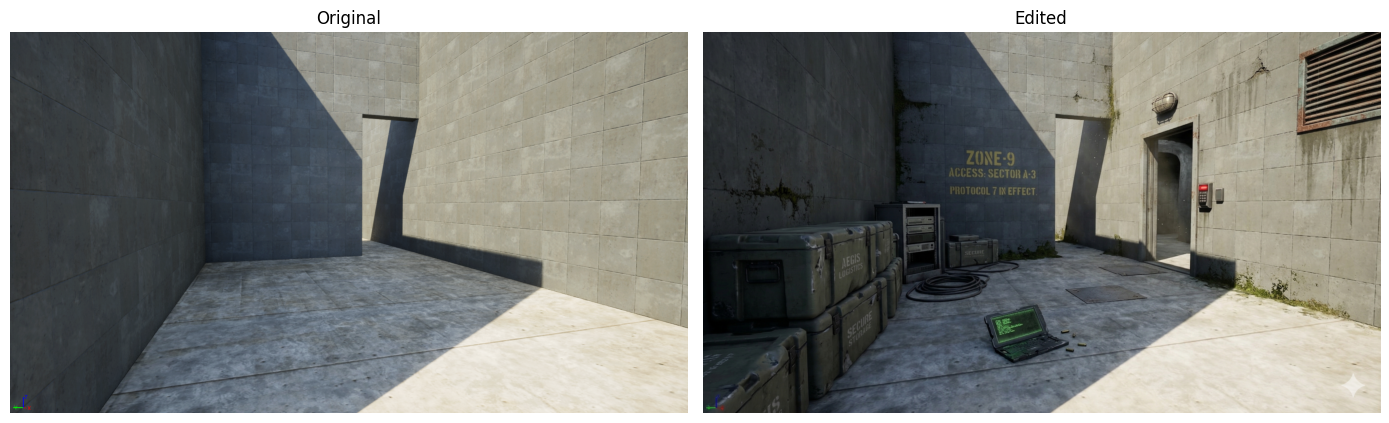

Working at 1526x858


In [10]:
def load_exr_rgb(path):
    exr = OpenEXR.InputFile(str(path))
    dw  = exr.header()['dataWindow']
    w, h = dw.max.x - dw.min.x + 1, dw.max.y - dw.min.y + 1
    flt = Imath.PixelType(Imath.PixelType.FLOAT)
    rgb = np.stack(
        [np.frombuffer(exr.channel(c, flt), np.float32).reshape(h, w) for c in 'RGB'],
        axis=-1)
    return Image.fromarray(np.clip(rgb * 255, 0, 255).astype(np.uint8))

def load_image(path):
    p = str(path)
    return load_exr_rgb(p) if p.lower().endswith('.exr') else Image.open(p).convert('RGB')

files       = os.listdir(DATA_DIR)
gt_rgb_path = next(DATA_DIR / f for f in files
                   if f.endswith('.exr') and 'depth' not in f.lower() and 'scenedepth' not in f.lower())
edited_path = next(DATA_DIR / f for f in files
                   if 'edit' in f.lower() and f.endswith(('.png', '.jpg', '.exr')))

original_img   = load_image(gt_rgb_path)
edited_img     = load_image(edited_path)
h_img, w_img   = np.array(original_img).shape[:2]
edited_resized = (edited_img.resize((w_img, h_img), Image.BILINEAR)
                  if edited_img.size != original_img.size else edited_img)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(original_img);   axes[0].set_title('Original');  axes[0].axis('off')
axes[1].imshow(edited_resized); axes[1].set_title('Edited');    axes[1].axis('off')
plt.tight_layout(); plt.show()
print(f'Working at {w_img}x{h_img}')

In [11]:
_preprocess = transforms.Compose([
    transforms.Resize((504, 504)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def load_model(model_name):
    from robust_scene_change_detect.models import get_model_from_pretrained
    print(f'  Loading {model_name} ...')
    m = get_model_from_pretrained(model_name)
    if hasattr(m, 'module'):
        m = m.module
    return m.to(device).eval()


def run_inference(model, img1, img2):
    """Returns a (h_img, w_img) float32 probability map (0=unchanged, 1=changed)."""
    t0 = _preprocess(img1).unsqueeze(0).to(device)
    t1 = _preprocess(img2).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(t0, t1)          # (1, 504, 504, 2)
    prob_map = torch.softmax(pred, dim=-1)[0, :, :, 1].cpu().numpy()  # (504, 504)
    # resize to original image dimensions
    prob_full = np.array(
        Image.fromarray((prob_map * 255).astype(np.uint8)).resize((w_img, h_img), Image.BILINEAR)
    ).astype(np.float32) / 255.0
    return prob_full


def show_sweep(results, title, cols=4, baseline_key=None):
    names     = list(results.keys())
    n         = len(names)
    rows      = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 6 * rows))
    axes_flat = np.atleast_1d(axes).flatten()
    for i, name in enumerate(names):
        mask        = results[name]
        is_baseline = (name == baseline_key)
        ov = np.zeros((h_img, w_img, 4), dtype=np.float32)
        ov[mask] = [0, 0.45, 1, 0.55] if is_baseline else [1, 0, 0, 0.50]
        axes_flat[i].imshow(edited_resized)
        axes_flat[i].imshow(ov)
        label = f'{name}  [ref]' if is_baseline else name
        axes_flat[i].set_title(
            f'{label}\n{mask.mean()*100:.1f}% changed', fontsize=10,
            color='steelblue' if is_baseline else 'black',
            fontweight='bold'  if is_baseline else 'normal',
        )
        axes_flat[i].axis('off')
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()


def show_prob_maps(prob_maps, title, threshold=None):
    n = len(prob_maps)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    axes_flat = np.atleast_1d(axes)
    for i, (name, prob) in enumerate(prob_maps.items()):
        im = axes_flat[i].imshow(prob, cmap='magma', vmin=0, vmax=1)
        axes_flat[i].set_title(f'{name}\nrange: {prob.min():.2f}–{prob.max():.2f}', fontsize=10)
        axes_flat[i].axis('off')
        plt.colorbar(im, ax=axes_flat[i], fraction=0.046, pad=0.04)
        if threshold is not None:
            axes_flat[i].set_xlabel(f'threshold={threshold:.2f}  →  {(prob > threshold).mean()*100:.1f}% changed')
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()


# Cache for prob maps — loading each checkpoint takes ~30s, so we only do it once.
PROB_MAPS = {}

  Loading dino_2Cross_PSCD ...


Using cache found in C:\Users\parve/.cache\torch\hub\facebookresearch_dinov2_main


<All keys matched successfully>


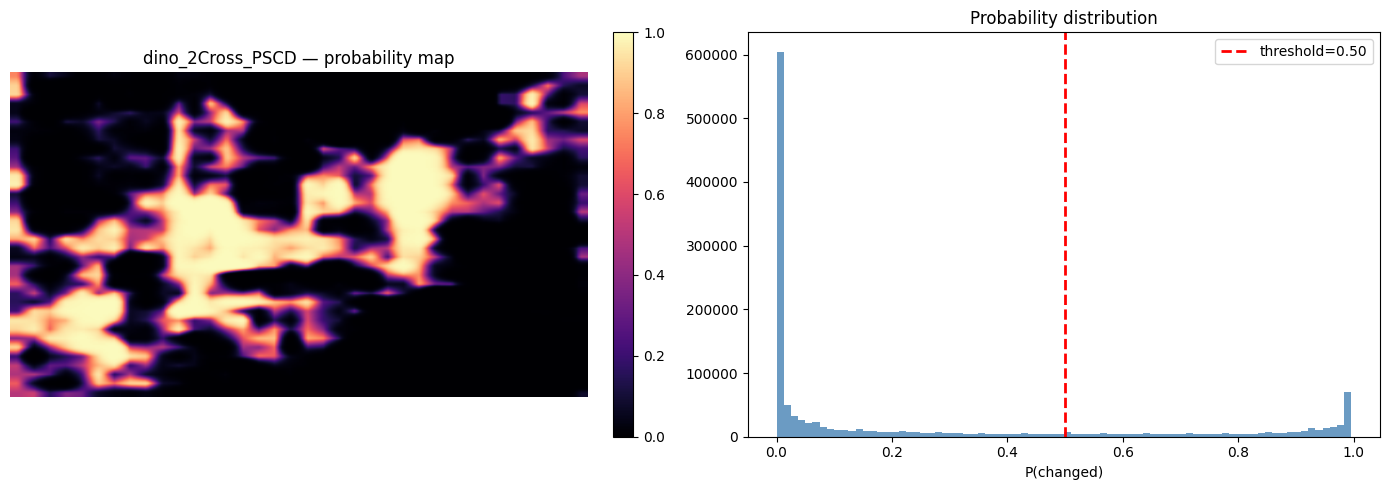

Baseline: model=dino_2Cross_PSCD  threshold=0.5
Prob range: 0.000–0.996  mean=0.250


In [12]:
from params import CROSSATTN_BASELINE

BASE_MODEL = CROSSATTN_BASELINE['model']
BASE_THR   = CROSSATTN_BASELINE['threshold']

gc.collect()
if device == 'cuda': torch.cuda.empty_cache()

if BASE_MODEL not in PROB_MAPS:
    _m = load_model(BASE_MODEL)
    PROB_MAPS[BASE_MODEL] = run_inference(_m, original_img, edited_resized)
    del _m
    gc.collect()
    if device == 'cuda': torch.cuda.empty_cache()
else:
    print(f'  {BASE_MODEL}: using cached prob map')

prob = PROB_MAPS[BASE_MODEL]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im = axes[0].imshow(prob, cmap='magma', vmin=0, vmax=1)
axes[0].set_title(f'{BASE_MODEL} — probability map')
axes[0].axis('off')
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
axes[1].hist(prob.ravel(), bins=80, color='steelblue', alpha=0.8)
axes[1].axvline(BASE_THR, color='r', ls='--', lw=2, label=f'threshold={BASE_THR:.2f}')
axes[1].set_title('Probability distribution')
axes[1].set_xlabel('P(changed)')
axes[1].legend()
plt.tight_layout(); plt.show()
print(f'Baseline: model={BASE_MODEL}  threshold={BASE_THR}')
print(f'Prob range: {prob.min():.3f}–{prob.max():.3f}  mean={prob.mean():.3f}')

## Sweep 1 — `threshold`

Run on the baseline model (`dino_2Cross_PSCD`). No recomputation needed — just threshold the cached probability map.

Look for the value where the changed object is fully covered without too much spillover into the background.

[1/7] thr=0.20  →  changed=34.1%
[2/7] thr=0.30  →  changed=30.0%
[3/7] thr=0.40  →  changed=26.7%
[4/7] thr=0.50  →  changed=23.7%
[5/7] thr=0.60  →  changed=20.9%
[6/7] thr=0.70  →  changed=18.4%
[7/7] thr=0.80  →  changed=15.6%


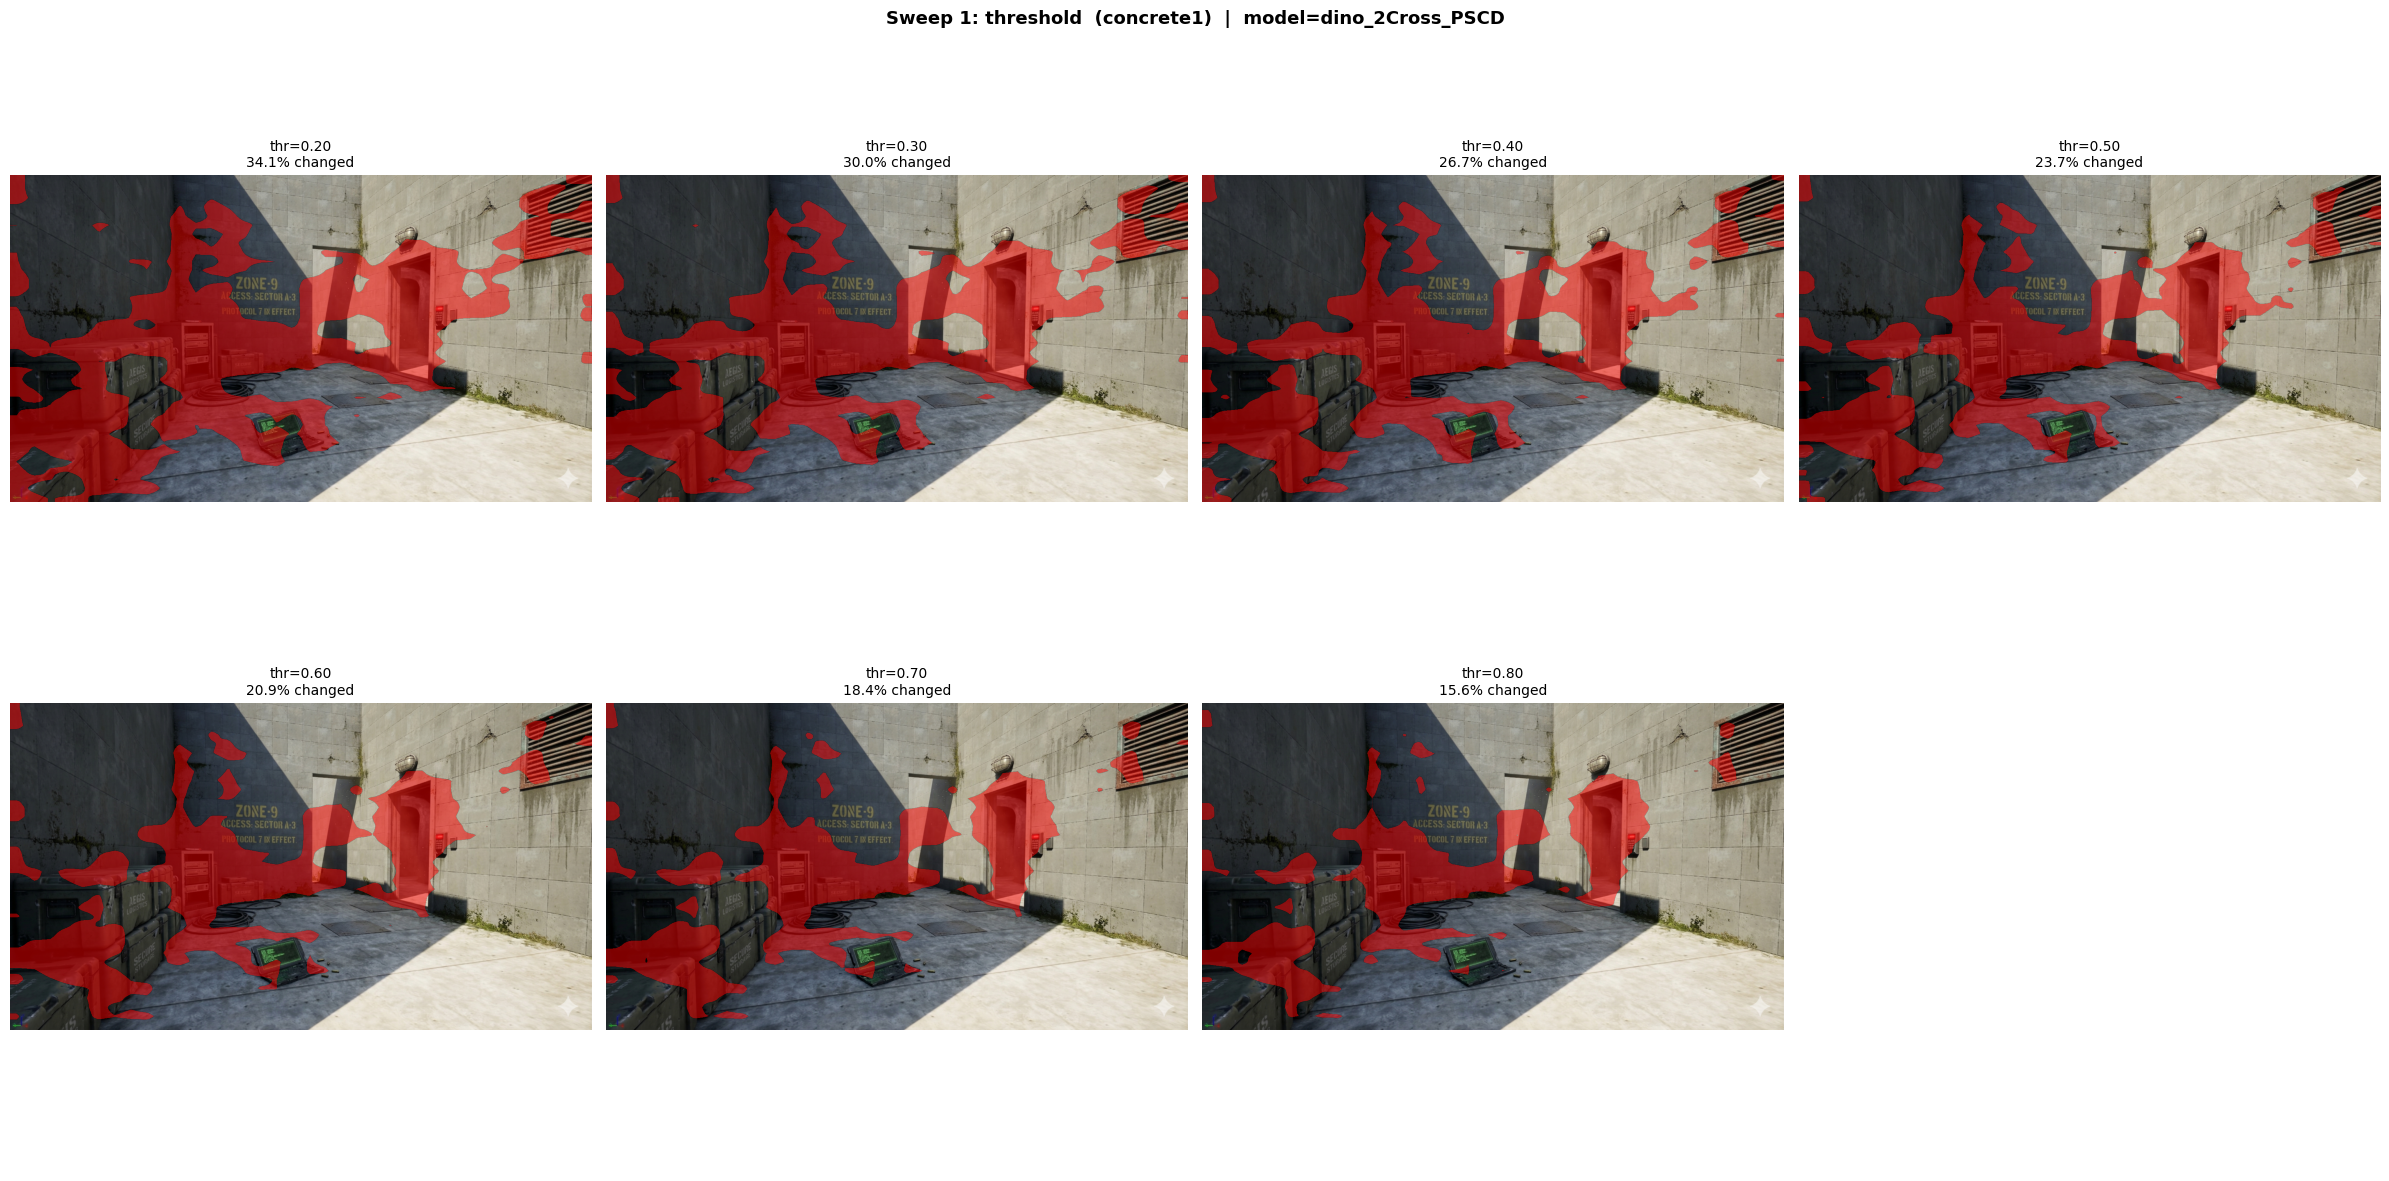

In [13]:
thr_values = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

prob = PROB_MAPS[BASE_MODEL]
thr_results = {}
for i, v in enumerate(thr_values, 1):
    name = f'thr={v:.2f}'
    mask = prob > v
    thr_results[name] = mask
    print(f'[{i}/{len(thr_values)}] {name}  →  changed={mask.mean()*100:.1f}%')

show_sweep(thr_results, f'Sweep 1: threshold  ({DATASET})  |  model={BASE_MODEL}', cols=4)

## Sweep 2 — model comparison

Loads all three checkpoints and runs inference. Each download is ~150 MB and cached locally after the first run.

| Model | Expected behaviour on our UE renders |
|---|---|
| `dino_2Cross_CMU` | Trained on viewpoint-change pairs — may over-detect small texture diffs |
| `dino_2Cross_PSCD` | Trained on same-viewpoint repeated photos — closest to our use case |
| `dino_2Cross_DiffCMU` | Cleaner CMU labels — somewhere between the two |

  Loading dino_2Cross_CMU ...


Using cache found in C:\Users\parve/.cache\torch\hub\facebookresearch_dinov2_main


<All keys matched successfully>
  dino_2Cross_PSCD: using cached prob map
  Loading dino_2Cross_DiffCMU ...


Using cache found in C:\Users\parve/.cache\torch\hub\facebookresearch_dinov2_main


<All keys matched successfully>


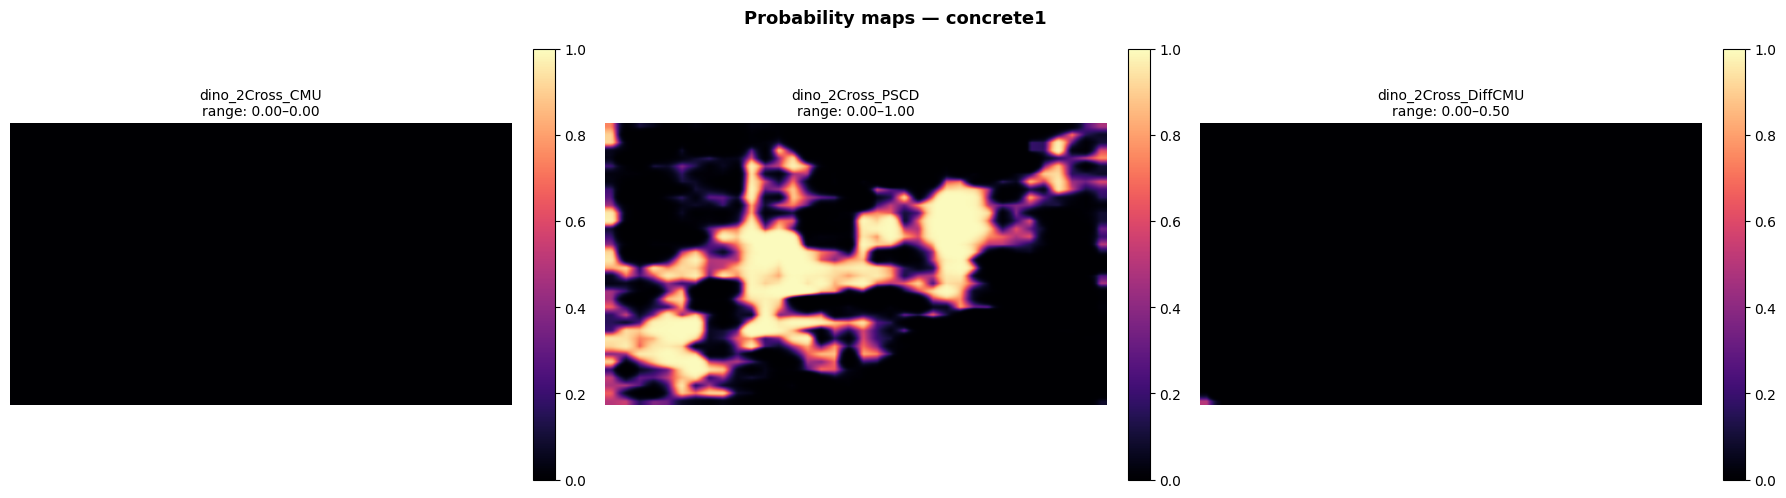

  dino_2Cross_CMU: changed=0.0%  (threshold=0.50)
  dino_2Cross_PSCD: changed=23.7%  (threshold=0.50)
  dino_2Cross_DiffCMU: changed=0.0%  (threshold=0.50)


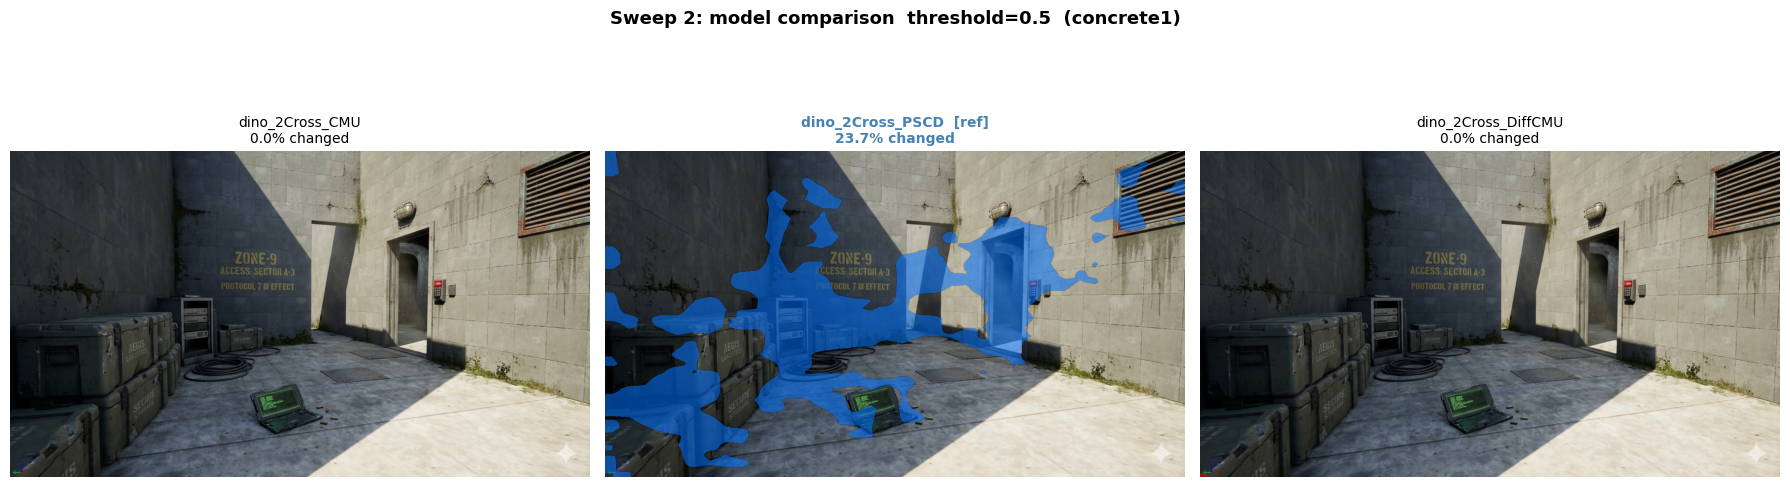

In [14]:
ALL_MODELS = ['dino_2Cross_CMU', 'dino_2Cross_PSCD', 'dino_2Cross_DiffCMU']

for name in ALL_MODELS:
    if name in PROB_MAPS:
        print(f'  {name}: using cached prob map')
        continue
    gc.collect()
    if device == 'cuda': torch.cuda.empty_cache()
    _m = load_model(name)
    PROB_MAPS[name] = run_inference(_m, original_img, edited_resized)
    del _m
    gc.collect()
    if device == 'cuda': torch.cuda.empty_cache()

# Show raw probability maps side by side
show_prob_maps(
    {n: PROB_MAPS[n] for n in ALL_MODELS},
    f'Probability maps — {DATASET}',
    threshold=BASE_THR,
)

# Show thresholded masks
model_results = {}
for name in ALL_MODELS:
    mask = PROB_MAPS[name] > BASE_THR
    model_results[name] = mask
    print(f'  {name}: changed={mask.mean()*100:.1f}%  (threshold={BASE_THR:.2f})')

show_sweep(
    model_results,
    f'Sweep 2: model comparison  threshold={BASE_THR}  ({DATASET})',
    cols=3,
    baseline_key=BASE_MODEL,
)

## Distribution comparison

The three models can have very different output scales — CMU / DiffCMU often concentrate probabilities
much lower than PSCD on synthetic renders. This explains why a fixed 0.5 threshold gives 0% for some
models. The survival function (right plot) shows exactly what fraction of pixels would be marked
changed at any given threshold.

  CMU         max=0.004  p95=0.000  p99=0.000
  PSCD        max=0.996  p95=0.984  p99=0.996
  DiffCMU     max=0.502  p95=0.000  p99=0.000


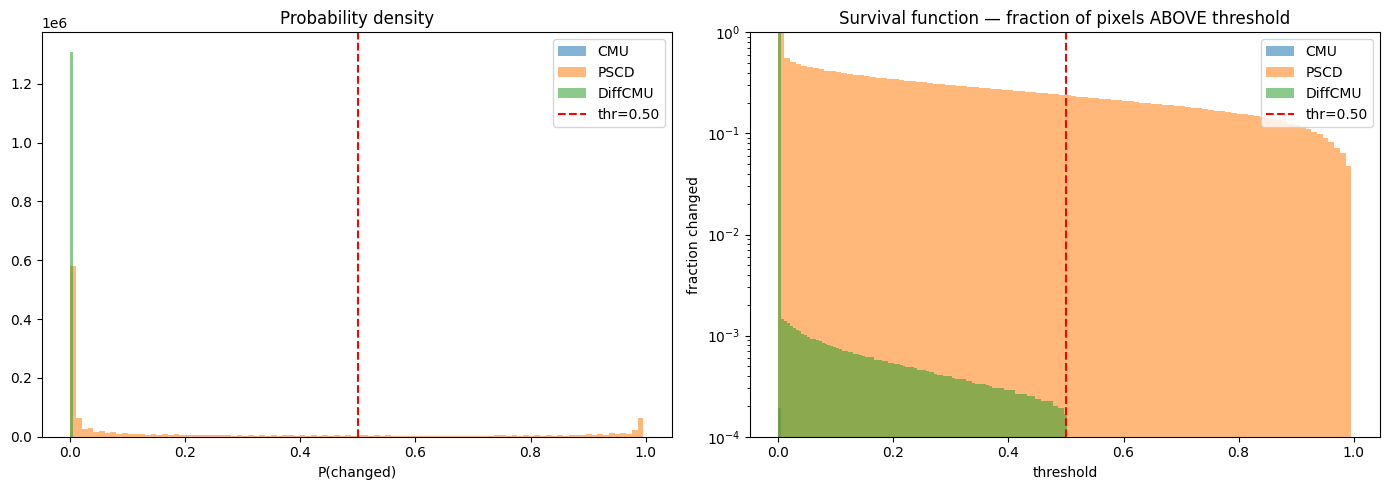

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'dino_2Cross_CMU': 'C0', 'dino_2Cross_PSCD': 'C1', 'dino_2Cross_DiffCMU': 'C2'}
for name in ALL_MODELS:
    if name not in PROB_MAPS:
        continue
    prob  = PROB_MAPS[name]
    label = name.replace('dino_2Cross_', '')
    axes[0].hist(prob.ravel(), bins=100, alpha=0.55, color=colors[name], label=label)
    axes[1].hist(prob.ravel(), bins=100, alpha=0.55, color=colors[name], label=label,
                 cumulative=-1, density=True)
    p95 = np.percentile(prob.ravel(), 95)
    p99 = np.percentile(prob.ravel(), 99)
    print(f'  {label:10s}  max={prob.max():.3f}  p95={p95:.3f}  p99={p99:.3f}')

for ax in axes:
    ax.axvline(0.50, color='r', ls='--', lw=1.5, label='thr=0.50')
axes[0].set_title('Probability density')
axes[0].set_xlabel('P(changed)')
axes[0].legend()
axes[1].set_title('Survival function — fraction of pixels ABOVE threshold')
axes[1].set_xlabel('threshold')
axes[1].set_ylabel('fraction changed')
axes[1].set_yscale('log')
axes[1].set_ylim(1e-4, 1)
axes[1].legend()
plt.tight_layout(); plt.show()

## Sweep 3 — per-model percentile threshold

Because the three models have different output scales, a single absolute threshold isn't fair.
This sweep uses **percentile thresholds** — e.g. `top5%` marks the 5% of pixels with the highest
changed-probability as changed. This is directly comparable across all models regardless of their
output scale. The absolute threshold value is printed next to each label so you can copy it into Combos.


--- CMU ---
  top20%  →  thr=0.000  changed=0.0%
  top15%  →  thr=0.000  changed=0.0%
  top10%  →  thr=0.000  changed=0.0%
  top 5%  →  thr=0.000  changed=0.0%
  top 2%  →  thr=0.000  changed=0.0%
  top 1%  →  thr=0.000  changed=0.0%


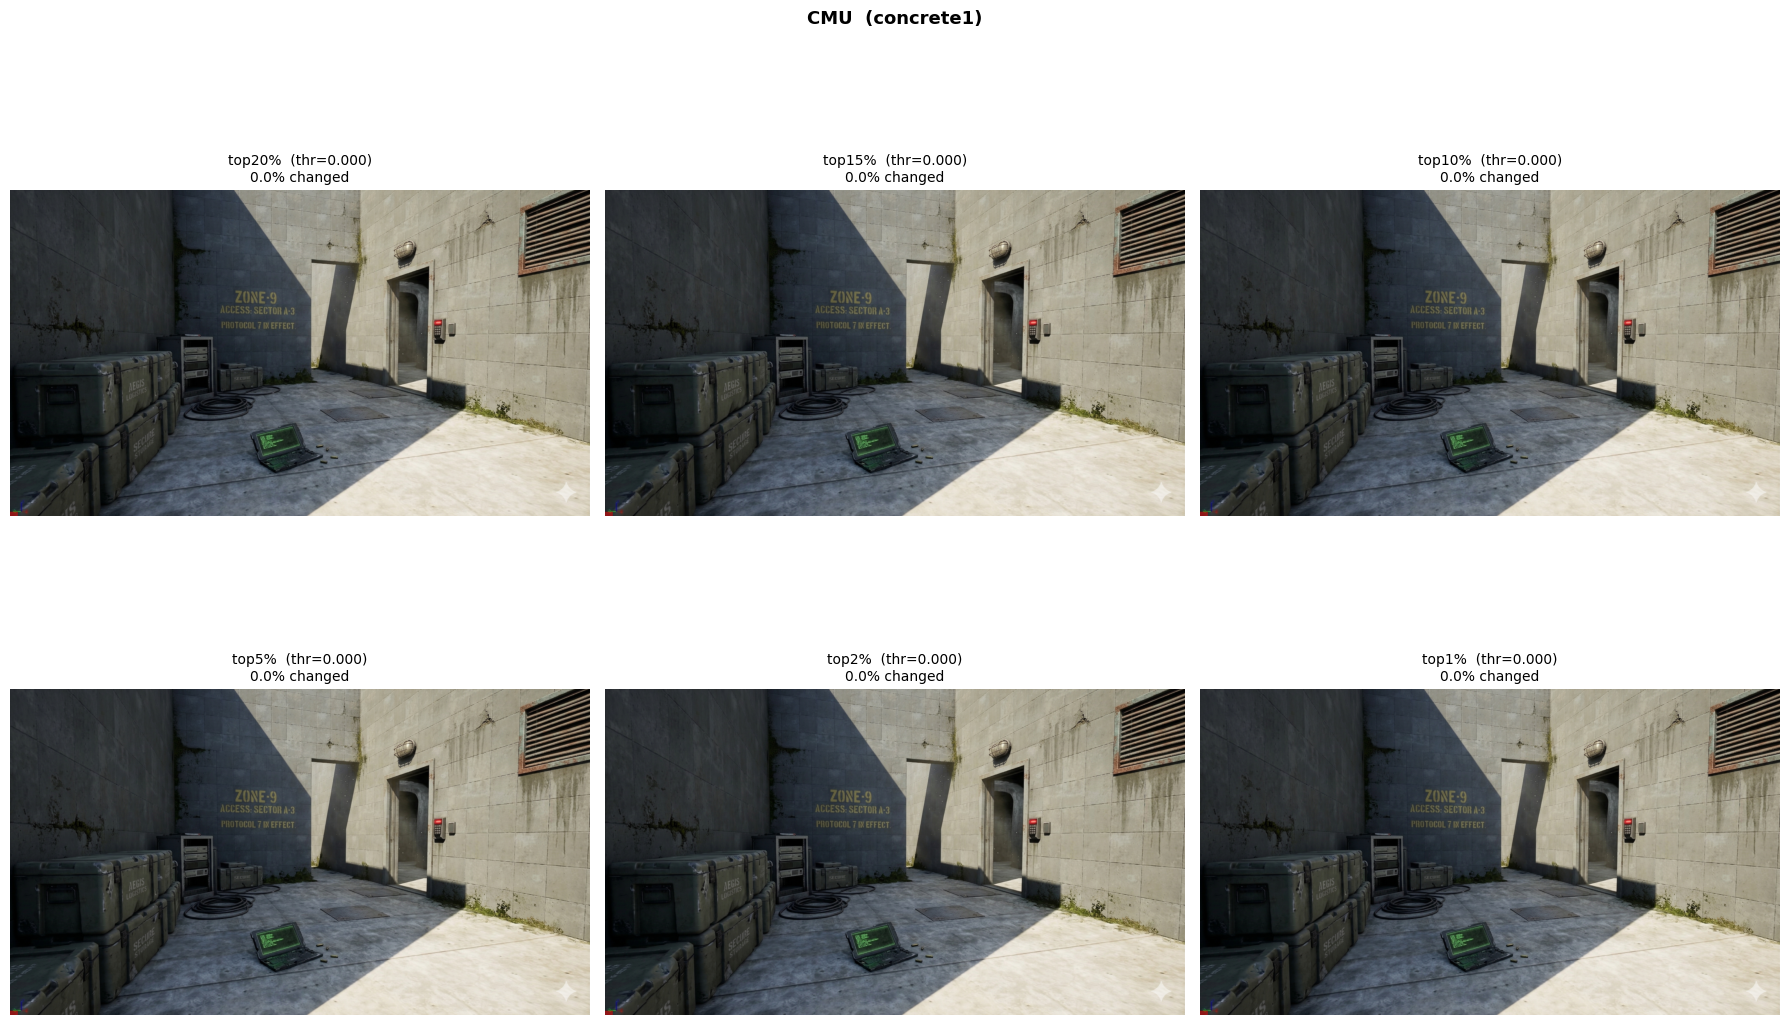


--- PSCD ---
  top20%  →  thr=0.635  changed=20.0%
  top15%  →  thr=0.824  changed=14.9%
  top10%  →  thr=0.933  changed=9.8%
  top 5%  →  thr=0.984  changed=4.8%
  top 2%  →  thr=0.996  changed=0.0%
  top 1%  →  thr=0.996  changed=0.0%


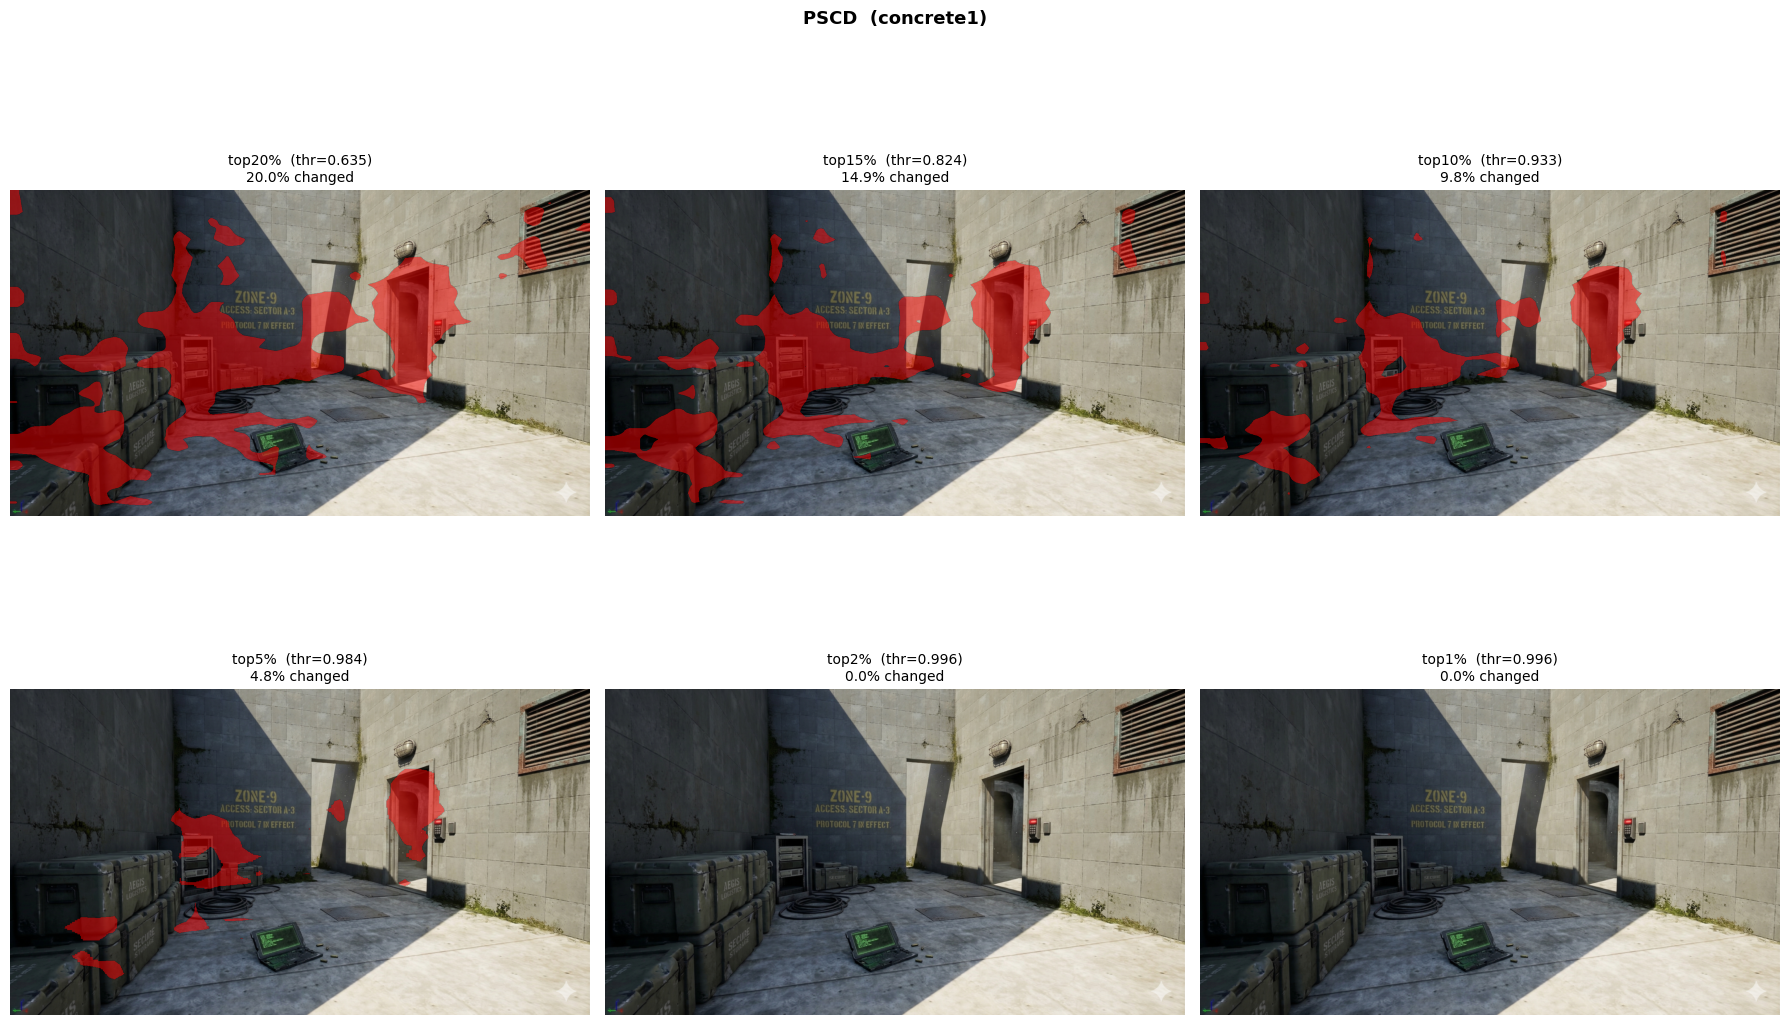


--- DiffCMU ---
  top20%  →  thr=0.000  changed=0.2%
  top15%  →  thr=0.000  changed=0.2%
  top10%  →  thr=0.000  changed=0.2%
  top 5%  →  thr=0.000  changed=0.2%
  top 2%  →  thr=0.000  changed=0.2%
  top 1%  →  thr=0.000  changed=0.2%


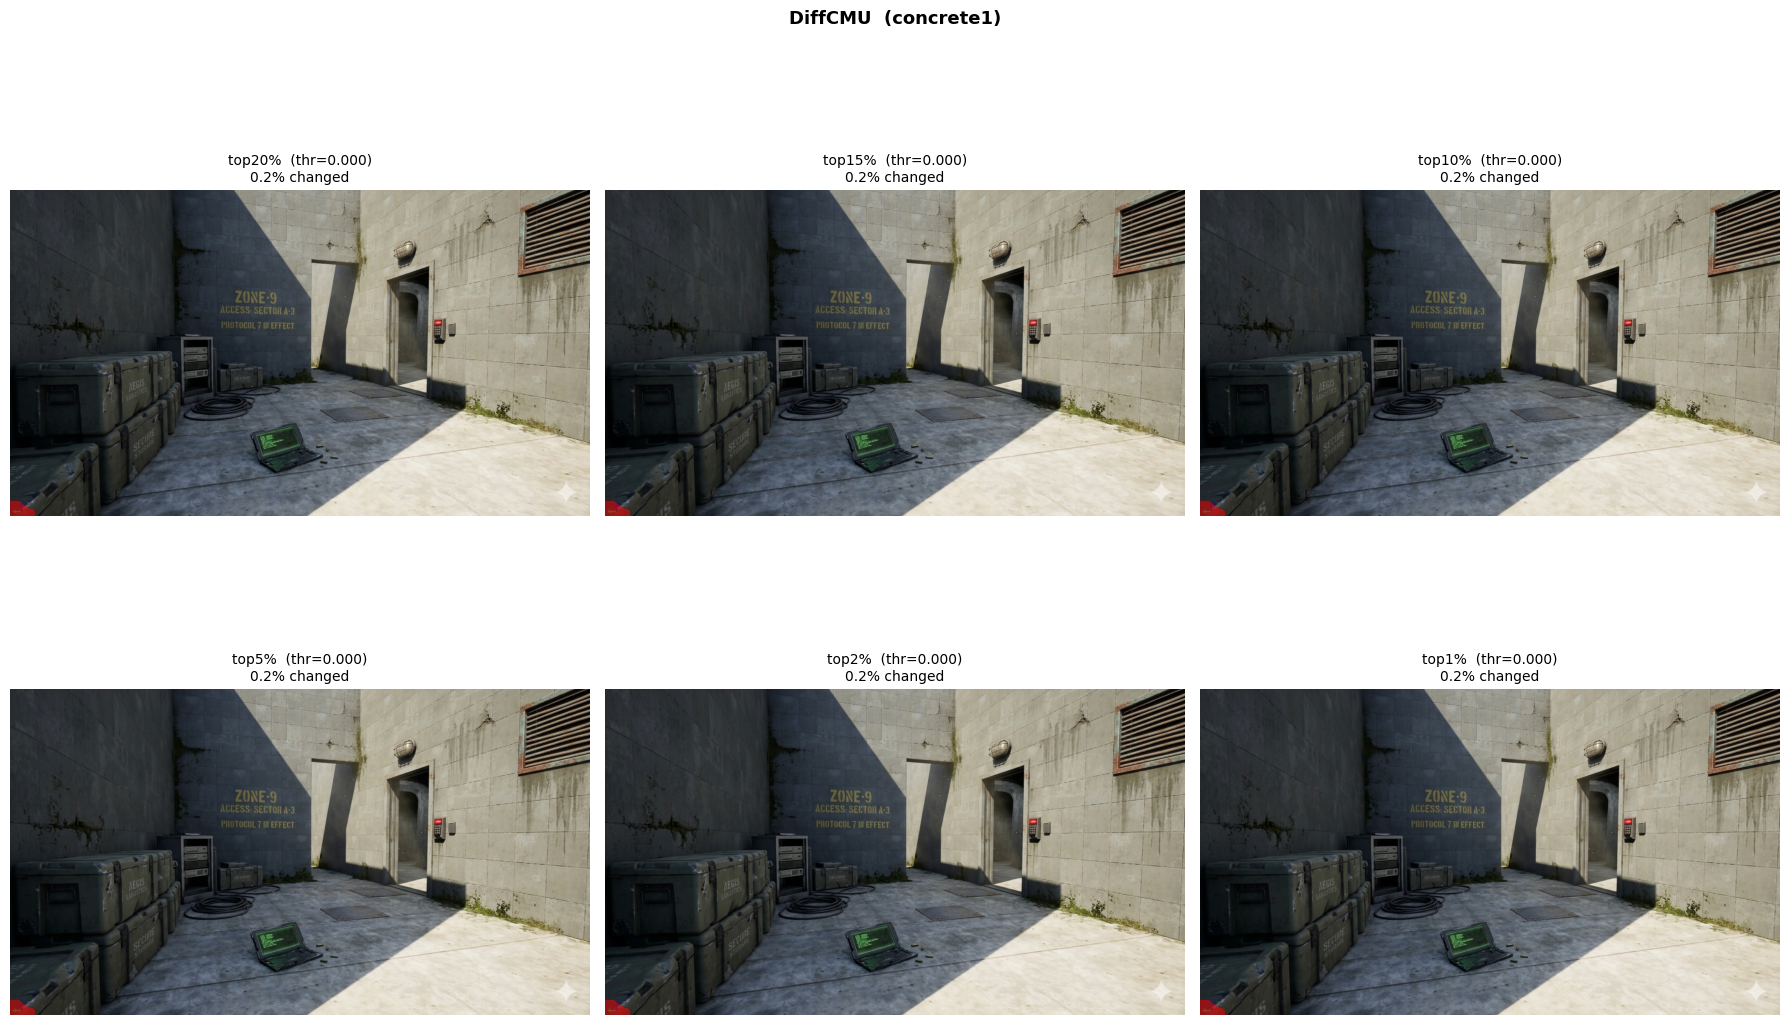

In [16]:
# fraction of pixels to mark as changed — adjust to bracket your edit size
top_pct_values = [20, 15, 10, 5, 2, 1]

for model_name in ALL_MODELS:
    if model_name not in PROB_MAPS:
        print(f'  {model_name} not cached — run Sweep 2 first'); continue
    prob  = PROB_MAPS[model_name]
    label = model_name.replace('dino_2Cross_', '')
    print(f'\n--- {label} ---')
    pct_results = {}
    for pct in top_pct_values:
        thr  = float(np.percentile(prob.ravel(), 100 - pct))
        mask = prob > thr
        name = f'top{pct}%  (thr={thr:.3f})'
        pct_results[name] = mask
        print(f'  top{pct:2d}%  →  thr={thr:.3f}  changed={mask.mean()*100:.1f}%')
    show_sweep(pct_results, f'{label}  ({DATASET})', cols=3)

## Combos — best threshold per model

Fill in your preferred thresholds from Sweeps 1 & 3. Use the absolute `thr=X.XXX` values printed
by Sweep 3 — they're already calibrated to each model's output scale. All runs from the cache.

  PSCD_thr0.50: thr=0.500  changed=23.7%
  CMU_top5pct: thr=0.000  changed=0.0%
  DiffCMU_top5pct: thr=0.000  changed=0.2%


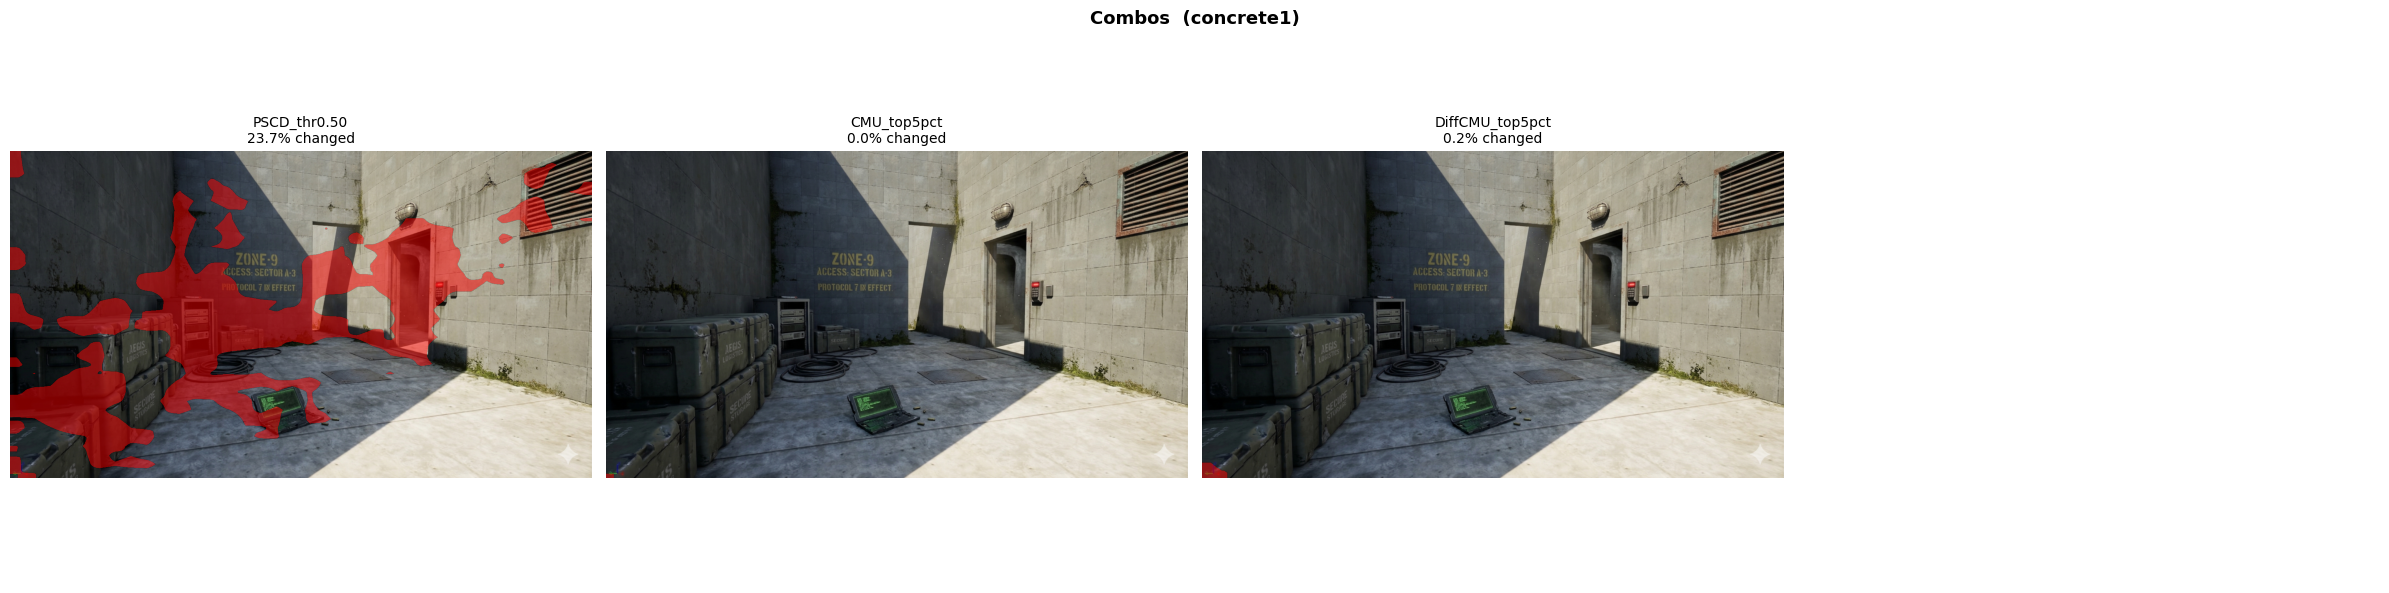

In [17]:
# <- edit thresholds with your picks from Sweeps 1 & 3
# Use the absolute thr=X.XXX values printed by Sweep 3 for CMU / DiffCMU.
# None = auto top-5% percentile (safe default while exploring).
combo_configs = {
    'PSCD_thr0.50':    ('dino_2Cross_PSCD',    0.50),
    'CMU_top5pct':     ('dino_2Cross_CMU',     None),
    'DiffCMU_top5pct': ('dino_2Cross_DiffCMU', None),
    # paste in specific values once you've read them from Sweep 3, e.g.:
    # 'CMU_thr0.08':     ('dino_2Cross_CMU',     0.08),
    # 'DiffCMU_thr0.06': ('dino_2Cross_DiffCMU', 0.06),
}

combo_results = {}
for label, (model_name, thr) in combo_configs.items():
    if model_name not in PROB_MAPS:
        print(f'  {model_name} not yet in cache — run Sweep 2 first'); continue
    prob = PROB_MAPS[model_name]
    if thr is None:
        thr = float(np.percentile(prob.ravel(), 95))   # top 5%
    mask = prob > thr
    combo_results[label] = mask
    print(f'  {label}: thr={thr:.3f}  changed={mask.mean()*100:.1f}%')

show_sweep(combo_results, f'Combos  ({DATASET})', cols=4)

In [18]:
gc.collect()
if device == 'cuda': torch.cuda.empty_cache()
print('Done. Prob maps cached in PROB_MAPS — re-run combo cell freely without reloading.')

Done. Prob maps cached in PROB_MAPS — re-run combo cell freely without reloading.
